# Predictive Modeling: Task Success Prediction

This notebook uses logistic regression to understand what factors contribute to task success, using:
- Message count (agent effort)
- Rubric criteria (Environmental Barrier, Instruction Following, Self Correction, Tool Use, Verification)
- Fixed effects for benchmark and model

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import re
from pathlib import Path
from matplotlib.lines import Line2D

results_dir = Path.cwd()
print(f"Results directory: {results_dir}")

Results directory: /Users/peterkirgis/Documents/hal-paper-analysis/qualitative/results


## 1. Load and Prepare Data

In [28]:
# Load compiled rubrics data
df = pd.read_csv(results_dir / 'compiled_rubrics.csv')

print(f"Loaded {len(df)} rows")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 10405 rows
Columns: ['benchmark_id', 'rubric', 'model', 'task_id', 'agent_run_id', 'eval_is_successful', 'label', 'output_explanation.text', 'docent_message_count', 'eval_has_successful_subtasks', 'eval_answer', 'eval_score']


,benchmark_id,rubric,model,task_id,agent_run_id,eval_is_successful,label,output_explanation.text,docent_message_count,eval_has_successful_subtasks,eval_answer,eval_score
0,scicode,Instruction Following,openai/claude-3-7-sonnet-20250219,54,bf6bfc47-5547-4dd7-a0c4-2c52f3e123c2,False,no match,The final cell contains a single Python code b...,111,False,NaN,NaN
1,scicode,Instruction Following,openai/claude-3-7-sonnet-20250219_high,24,8b2c40dc-4b49-4173-a42b-57d22f7eec31,False,no match,The final cell consists solely of a Python cod...,86,False,NaN,NaN
2,scicode,Instruction Following,openai/claude-3-7-sonnet-20250219,35,193fa9e6-f306-4884-aacc-f8b46b451af9,False,no match,The final cell contains a properly formatted P...,88,True,NaN,NaN
3,scicode,Instruction Following,openai/claude-3-7-sonnet-20250219_high,43,1380982b-c022-4357-a5a9-3e225649183d,False,no match,The final cell consists solely of a Python fun...,87,True,NaN,NaN
4,scicode,Instruction Following,openai/claude-3-7-sonnet-20250219,18,248ce19c-83ab-4152-8058-f21fbaa95063,False,no match,The final cell consists solely of a valid Pyth...,60,False,NaN,NaN


In [29]:
# Standardize model names
df['model'] = df['model'].apply(lambda x: x.split('/')[-1])

def standardize_model_name(model_name):
    """Remove dates, version numbers, and clean up model names."""
    name = re.sub(r'-?\d{4}-?\d{2}-?\d{2}', '', model_name)
    name = re.sub(r'-\d{3}$', '', name)
    name = name.strip('-_')
    return name

df['model'] = df['model'].apply(standardize_model_name)

# Remove minimal reasoning models
df = df[df['model'] != 'gpt-5_minimal']

# Combine similar models
df['model'] = df['model'].replace({
    'o3': 'o3_medium',
    'gpt-5': 'gpt-5_high'
})

print(f"\nUnique models: {sorted(df['model'].unique())}")
print(f"\nModel counts:\n{df['model'].value_counts()}")


Unique models: ['DeepSeek-R1', 'DeepSeek-V3', 'claude-3-7-sonnet', 'claude-3-7-sonnet_high', 'claude-opus-4.1', 'claude-opus-4.1_high', 'gemini-2.0-flash', 'gpt-4.1', 'gpt-5_high', 'o3_medium', 'o4-mini_high', 'o4-mini_low']

Model counts:
model
o4-mini_low               943
o4-mini_high              938
gemini-2.0-flash          936
gpt-4.1                   933
DeepSeek-V3               922
o3_medium                 919
gpt-5_high                899
claude-opus-4.1           854
DeepSeek-R1               846
claude-3-7-sonnet         675
claude-3-7-sonnet_high    673
claude-opus-4.1_high      620
Name: count, dtype: int64


In [30]:
# Create task_success outcome variable
def compute_outcome(row):
    """Benchmark-specific success criteria."""
    if row['benchmark_id'] == 'assistantbench':
        return row['eval_score'] > 0.7
    elif row['benchmark_id'] == 'scicode':
        return row['eval_has_successful_subtasks']
    else:
        return row['eval_is_successful']
    
df['task_success'] = df.apply(compute_outcome, axis=1)

print(f"Task success distribution:")
print(df['task_success'].value_counts())
print(f"\nOverall success rate: {df['task_success'].mean():.2%}")

Task success distribution:
task_success
False    6663
True     3495
Name: count, dtype: int64

Overall success rate: 34.41%


In [31]:
# Convert rubric labels to binary columns
label_df = df[['benchmark_id', 'task_id', 'model', 'docent_message_count', 
               'task_success', 'rubric', 'label']].copy()

# Binary encoding: True if "match", False otherwise
label_df['label'] = label_df['label'].apply(lambda x: x == "match")

# Pivot to create rubric columns
model_df = label_df.pivot_table(
    index=['benchmark_id', 'task_id', 'model', 'docent_message_count', 'task_success'],
    columns='rubric',
    values='label',
    fill_value=False
).reset_index()

# Define rubric features
rubric_features = ['Environmental Barrier', 'Instruction Following', 
                   'Self Correction', 'Tool Use', 'Verification']

print(f"\nPivoted dataframe shape: {model_df.shape}")
print(f"Columns: {model_df.columns.tolist()}")
print(f"\nRubric feature distributions:")
for col in rubric_features:
    if col in model_df.columns:
        print(f"  {col}: {model_df[col].sum()} matches ({model_df[col].mean():.1%})")

model_df.head()


Pivoted dataframe shape: (2069, 10)
Columns: ['benchmark_id', 'task_id', 'model', 'docent_message_count', 'task_success', 'Environmental Barrier', 'Instruction Following', 'Self Correction', 'Tool Use', 'Verification']

Rubric feature distributions:
  Environmental Barrier: 568.0 matches (27.5%)
  Instruction Following: 563.0 matches (27.2%)
  Self Correction: 1111.0 matches (53.7%)
  Tool Use: 1226.0 matches (59.3%)
  Verification: 1026.0 matches (49.6%)


rubric,benchmark_id,task_id,model,docent_message_count,task_success,Environmental Barrier,Instruction Following,Self Correction,Tool Use,Verification
0,assistantbench,0ec4371851b96837b0a81b3dd3df401415061bb532fbaf...,DeepSeek-R1,14,False,1.0,0.0,0.0,0.0,0.0
1,assistantbench,0ec4371851b96837b0a81b3dd3df401415061bb532fbaf...,DeepSeek-V3,24,False,0.0,1.0,0.0,0.0,0.0
2,assistantbench,0ec4371851b96837b0a81b3dd3df401415061bb532fbaf...,claude-3-7-sonnet,29,False,1.0,0.0,0.0,0.0,1.0
3,assistantbench,0ec4371851b96837b0a81b3dd3df401415061bb532fbaf...,claude-3-7-sonnet_high,24,False,0.0,0.0,0.0,0.0,0.0
4,assistantbench,0ec4371851b96837b0a81b3dd3df401415061bb532fbaf...,claude-opus-4.1,56,False,0.0,1.0,0.0,1.0,1.0


## 2. Logistic Regression with Fixed Effects

Using logistic regression for causal inference with interpretable odds ratios.

In [32]:
# Prepare data for logistic regression
causal_df = model_df.copy()

# Standardize message count for interpretability (per 10 messages)
causal_df['5 Agent Steps'] = causal_df['docent_message_count'] / 10

# Ensure rubric features are integers
for col in rubric_features:
    causal_df[col] = causal_df[col].astype(int)

# Create dummy variables for benchmark and model (fixed effects)
benchmark_dummies = pd.get_dummies(causal_df['benchmark_id'], prefix='benchmark', drop_first=True)
model_dummies = pd.get_dummies(causal_df['model'], prefix='model', drop_first=True)

# Combine features: rubrics + message count + fixed effects
X_causal = pd.concat([
    causal_df[['5 Agent Steps']],
    causal_df[rubric_features],
    benchmark_dummies,
    model_dummies
], axis=1)

# Ensure all columns are numeric
X_causal = X_causal.astype(float)

# Add constant for statsmodels
X_causal = sm.add_constant(X_causal)

y_causal = causal_df['task_success'].astype(int)

print(f"Dataset shape: {X_causal.shape}")
print(f"Features: {X_causal.shape[1]} (including intercept, {len(benchmark_dummies.columns)} benchmark FE, {len(model_dummies.columns)} model FE)")
print(f"Sample size: {len(y_causal)}")
print(f"Success rate: {y_causal.mean():.2%}")

Dataset shape: (2069, 21)
Features: 21 (including intercept, 3 benchmark FE, 11 model FE)
Sample size: 2069
Success rate: 34.27%


In [33]:
# Fit logistic regression model
print("Fitting Logistic Regression Model...")
print("=" * 80)

logit_model = sm.Logit(y_causal, X_causal)
result = logit_model.fit(maxiter=100, disp=0)

print(f"\nModel Fit Summary:")
print(f"  Converged: {result.mle_retvals['converged']}")
print(f"  Observations: {result.nobs:.0f}")
print(f"  Log-Likelihood: {result.llf:.2f}")
print(f"  Pseudo R-squared: {result.prsquared:.3f}")
print(f"  AIC: {result.aic:.2f}")
print(f"  BIC: {result.bic:.2f}")

Fitting Logistic Regression Model...

Model Fit Summary:
  Converged: True
  Observations: 2069
  Log-Likelihood: -1092.64
  Pseudo R-squared: 0.178
  AIC: 2227.27
  BIC: 2345.60


In [34]:
# Extract results for key variables (excluding fixed effects)
key_vars = ['5 Agent Steps'] + rubric_features

results_list = []
for var in key_vars:
    if var in result.params.index:
        coef = result.params[var]
        se = result.bse[var]
        z_stat = result.tvalues[var]
        p_value = result.pvalues[var]
        
        # Compute odds ratio and 95% CI
        odds_ratio = np.exp(coef)
        ci_lower = np.exp(coef - 1.96 * se)
        ci_upper = np.exp(coef + 1.96 * se)
        
        results_list.append({
            'Variable': var,
            'Coefficient': coef,
            'Std Error': se,
            'z-statistic': z_stat,
            'P-value': p_value,
            'Odds Ratio': odds_ratio,
            'OR 95% CI Lower': ci_lower,
            'OR 95% CI Upper': ci_upper
        })

results_df = pd.DataFrame(results_list)

print("\n" + "=" * 80)
print("Effect Sizes (Odds Ratios)")
print("=" * 80)
print(results_df.to_string(index=False))
print("\n" + "=" * 80)


Effect Sizes (Odds Ratios)
             Variable  Coefficient  Std Error  z-statistic      P-value  Odds Ratio  OR 95% CI Lower  OR 95% CI Upper
        5 Agent Steps     0.037269   0.013794     2.701906 6.894334e-03    1.037973         1.010286         1.066418
Environmental Barrier    -0.603746   0.130881    -4.612951 3.969914e-06    0.546760         0.423047         0.706650
Instruction Following    -1.159998   0.149007    -7.784875 6.978237e-15    0.313487         0.234090         0.419813
      Self Correction     0.459519   0.135826     3.383131 7.166451e-04    1.583312         1.213245         2.066257
             Tool Use    -0.561918   0.200537    -2.802070 5.077588e-03    0.570114         0.384823         0.844622
         Verification     0.628520   0.152278     4.127435 3.668319e-05    1.874833         1.391043         2.526880



## 3. Forest Plot of Odds Ratios

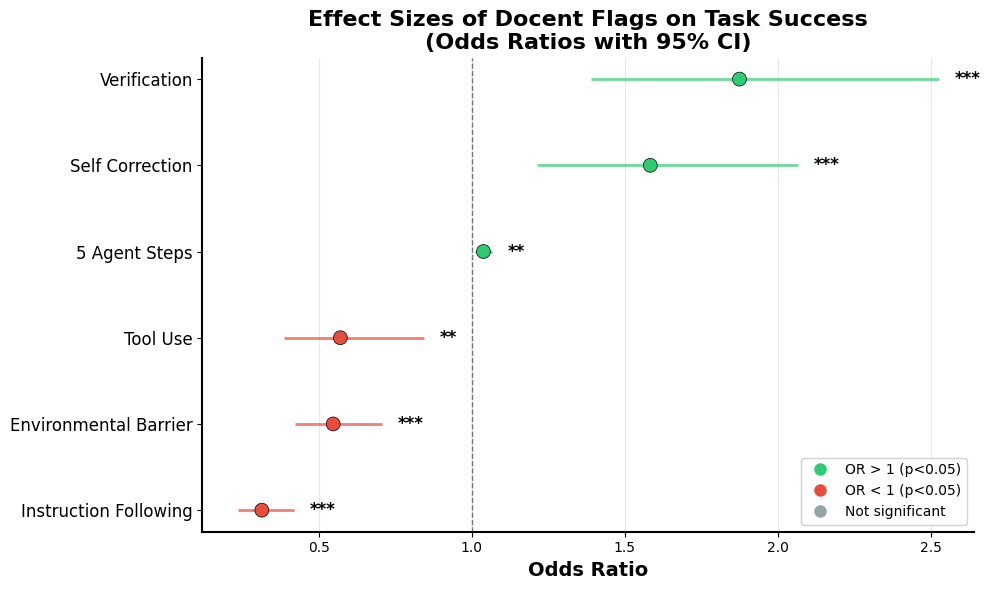

In [36]:
# Forest plot of Odds Ratios with 95% confidence intervals
fig, ax = plt.subplots(figsize=(10, 6))

# Sort by odds ratio for better visualization
plot_df = results_df.sort_values('Odds Ratio', ascending=True).reset_index(drop=True)

# Y positions
y_pos = np.arange(len(plot_df))

# Color based on significance and direction (OR > 1 or < 1)
colors = []
for _, row in plot_df.iterrows():
    if row['P-value'] < 0.05:
        colors.append('#2ecc71' if row['Odds Ratio'] > 1 else '#e74c3c')
    else:
        colors.append('#95a5a6')

# Plot horizontal error bars (confidence intervals)
ax.hlines(y=y_pos, xmin=plot_df['OR 95% CI Lower'], xmax=plot_df['OR 95% CI Upper'], 
          color=colors, linewidth=2, alpha=0.7)

# Plot point estimates
ax.scatter(plot_df['Odds Ratio'], y_pos, color=colors, s=100, zorder=3, edgecolor='black', linewidth=0.5)

# Add vertical line at 1 (null effect)
ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Labels
ax.set_yticks(y_pos)
ax.set_yticklabels(plot_df['Variable'], fontsize=12)
ax.set_xlabel('Odds Ratio', fontsize=14, fontweight='bold')
ax.set_title('Effect Sizes of Docent Flags on Task Success\n(Odds Ratios with 95% CI)', fontsize=16, fontweight='bold')

# Add significance stars
for i, row in plot_df.iterrows():
    if row['P-value'] < 0.001:
        stars = '***'
    elif row['P-value'] < 0.01:
        stars = '**'
    elif row['P-value'] < 0.05:
        stars = '*'
    else:
        stars = ''
    
    if stars:
        ax.text(row['OR 95% CI Upper'] + 0.05, i, stars, va='center', ha='left', fontsize=12, fontweight='bold')

# Clean up spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.5)
ax.spines['bottom'].set_linewidth(1.5)

# Grid
ax.grid(True, axis='x', alpha=0.3, linestyle='-')

# Legend
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='OR > 1 (p<0.05)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='OR < 1 (p<0.05)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#95a5a6', markersize=10, label='Not significant'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

## 4. Key Findings

In [ ]:
print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

# Significant positive effects (OR > 1)
positive_effects = results_df[(results_df['P-value'] < 0.05) & (results_df['Odds Ratio'] > 1)]
print(f"\n1. Factors that INCREASE task success (OR > 1, p < 0.05):")
for _, row in positive_effects.sort_values('Odds Ratio', ascending=False).iterrows():
    print(f"   - {row['Variable']}: OR = {row['Odds Ratio']:.2f} (95% CI: {row['OR 95% CI Lower']:.2f}-{row['OR 95% CI Upper']:.2f})")

# Significant negative effects (OR < 1)
negative_effects = results_df[(results_df['P-value'] < 0.05) & (results_df['Odds Ratio'] < 1)]
print(f"\n2. Factors that DECREASE task success (OR < 1, p < 0.05):")
for _, row in negative_effects.sort_values('Odds Ratio', ascending=True).iterrows():
    print(f"   - {row['Variable']}: OR = {row['Odds Ratio']:.2f} (95% CI: {row['OR 95% CI Lower']:.2f}-{row['OR 95% CI Upper']:.2f})")

# Model fit
print(f"\n3. Model Fit:")
print(f"   - Pseudo R-squared: {result.prsquared:.3f}")
print(f"   - Sample size: {result.nobs:.0f}")

print("\n" + "=" * 80)